## 8.9 Assignment 8: Support Vector Machine (SVM)

#### Rahul Rastogi

## Objective
The task was to predict the **Portuguese outcome** of historical naval battles (victory, draw, or defeat) using:

- Portuguese, Dutch, and English ship counts  
- Ratio of Portuguese to Dutch/British ships  
- Spanish involvement (0/1 flag)

**Outcome variable:**  
`-1 = Defeat`, `0 = Draw`, `1 = Victory`

In [1]:
# Step 0: Imports
import io
import sys
import urllib.request
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# Step 1: Load data
URL = "https://users.stat.ufl.edu/~winner/data/armada.dat"

COLS = [
    "Battle", "Year", "Portuguese ships", "Dutch ships", "English ships",
    "Ratio", "Spanish Involvement", "Portuguese outcome"
]

def load_armada(url=URL):
    raw = urllib.request.urlopen(url).read().decode("utf-8", errors="ignore")

    # Try 1: split on 2+ spaces (keeps single spaces inside 'Battle' names intact)
    try:
        df = pd.read_csv(io.StringIO(raw), sep=r"\s{2,}", engine="python")
    except Exception:
        df = None

    # Try 2: fall back to fixed-width parsing (very tolerant of ragged whitespace)
    if df is None or df.shape[1] < 7:
        df = pd.read_fwf(io.StringIO(raw))

    # Normalize headers (if pandas didn’t read a proper header row)
    if not set(COLS).issubset(set(df.columns)):
        # Sometimes header lines get mangled; coerce to expected schema
        # Keep the first 8 columns and rename them to our expected names.
        df = df.iloc[:, :8].copy()
        df.columns = COLS

    # Clean up types and compute missing fields safely
    def to_num(s):
        return pd.to_numeric(s, errors="coerce")

    for c in ["Year", "Portuguese ships", "Dutch ships", "English ships",
              "Spanish Involvement", "Portuguese outcome"]:
        df[c] = to_num(df[c])

    # If Ratio is missing or has NaNs, (re)compute: Portuguese / (Dutch+English)
    denom = (df["Dutch ships"].fillna(0) + df["English ships"].fillna(0)).replace(0, np.nan)
    df["Ratio"] = df.get("Ratio", pd.Series(index=df.index, dtype=float))
    df["Ratio"] = df["Ratio"].where(df["Ratio"].notna(), df["Portuguese ships"] / denom)
    df["Ratio"] = df["Ratio"].fillna(0.0)

    # Ensure binary 0/1 for Spanish involvement
    df["Spanish Involvement"] = df["Spanish Involvement"].fillna(0).astype(int)

    # Tidy final columns and types
    df["Battle"] = df["Battle"].astype(str).str.strip()
    df["Portuguese outcome"] = df["Portuguese outcome"].astype(int)

    return df

df = load_armada()
print(df.shape)
df

(27, 8)


,Battle,Year,Portuguese ships,Dutch ships,English ships,Ratio,Spanish Involvement,Portuguese outcome
0,Malacca Strait,1606,14,11,0,1.273,0,0
1,Ilha das Naus,1606,6,9,0,0.667,0,-1
2,Pulo Butum,1606,7,9,0,0.778,0,1
3,Surrat,1615,6,0,4,1.500,0,0
4,Ilha das Naus,1615,3,5,0,0.600,0,-1
5,Jask,1620,4,0,4,1.000,0,0
6,Hormuz,1622,6,0,5,1.200,0,-1
7,Mogincoal Shoals,1622,4,4,2,0.667,0,-1
8,Hormuz,1625,8,4,4,1.000,0,0
9,Goa,1636,6,4,0,1.500,0,0


In [2]:
# Step 2: Clean + feature engineering

# Standardize column names
df.columns = [c.strip().replace(" ", "_").replace("/", "_") for c in df.columns]

# Create Combined_British_Dutch
if "Dutch_ships" in df.columns and "English_ships" in df.columns:
    df["British_Dutch_total"] = df["Dutch_ships"].fillna(0) + df["English_ships"].fillna(0)
else:
    raise ValueError("Expected 'Dutch ships' and 'English ships' columns.")

# Ensure Spanish_Involvement is numeric 0/1
if "Spanish_Involvement" in df.columns:
    df["Spanish_Involvement"] = pd.to_numeric(df["Spanish_Involvement"], errors="coerce").fillna(0).astype(int)
else:
    raise ValueError("Expected 'Spanish Involvement' column.")

# Compute Ratio if missing: Portuguese / (Dutch + English), guard divide-by-zero
if "Ratio" not in df.columns:
    denom = df["British_Dutch_total"].replace(0, np.nan)
    df["Ratio"] = df["Portuguese_ships"] / denom
    df["Ratio"] = df["Ratio"].fillna(0.0)

# Target
if "Portuguese_outcome" not in df.columns:
    raise ValueError("Expected 'Portuguese outcome' as target column.")
y = df["Portuguese_outcome"].astype(int)

# Features (numeric only per instructions)
feature_cols = [
    "Portuguese_ships",
    "Dutch_ships",
    "English_ships",
    "British_Dutch_total",
    "Ratio",
    "Spanish_Involvement"
]
X = df[feature_cols].copy()

print("Class distribution (y):")
print(y.value_counts().sort_index())
X.describe()


Class distribution (y):
Portuguese_outcome
-1    10
 0    12
 1     5
Name: count, dtype: int64


,Portuguese_ships,Dutch_ships,English_ships,British_Dutch_total,Ratio,Spanish_Involvement
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,13.407407,13.814815,1.851852,15.666667,1.128778,0.481481
std,16.163252,22.608775,6.030077,22.276238,0.931028,0.509175
min,2.000000,0.000000,0.000000,3.000000,0.150000,0.000000
25%,5.500000,4.000000,0.000000,5.500000,0.633500,0.000000
50%,6.000000,8.000000,0.000000,9.000000,0.857000,0.000000
75%,14.000000,11.000000,0.000000,12.000000,1.386500,1.000000
max,69.000000,110.000000,31.000000,110.000000,4.636000,1.000000


In [3]:
# 3) Train/test split (stratified, because classes are -1/0/1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (20, 6)  Test size: (7, 6)


In [4]:
# ===== Step 4: Define CV strategy, models, and grids  =====
# Pick CV folds based on the rarest class in the TRAIN split to avoid "least populated class" warnings.
min_class = y_train.value_counts().min()
cv_splits = max(2, min(3, int(min_class)))  # use 2 or 3 folds depending on data size/rarity
cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)

# SVM (RBF) with class balancing; StandardScaler inside pipeline
svm_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", SVC(kernel="rbf",
                class_weight="balanced",
                decision_function_shape="ovr",
                random_state=RANDOM_STATE))
])
svm_grid = {
    "clf__C": [0.1, 1, 10],
    "clf__gamma": ["scale", 0.01, 0.001],
}

# Logistic Regression (multinomial is auto-chosen by lbfgs)
logreg_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="lbfgs"   # auto-selects multinomial where appropriate
    ))
])
logreg_grid = {
    "clf__C": [0.1, 1, 10],
    "clf__penalty": ["l2"],
}

# Random Forest with class balancing
rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample"
)
rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 5, 8],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2],
}


In [5]:
# ===== Step 5: Helper to fit with GridSearchCV and print clean reports =====
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    make_scorer, f1_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings

# Using macro-F1 to respect class imbalance
scorer = make_scorer(f1_score, average="macro")

def fit_and_report(name, estimator, grid):
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        cv=cv,
        scoring=scorer,
        n_jobs=1,       # avoid subprocess issues on some Windows/Python combos
        verbose=0,
        refit=True,
        return_train_score=False,
    )

    # Silence only the specific sklearn FutureWarning from logistic internals (if any)
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            category=FutureWarning,
            module=r"sklearn\.linear_model\._logistic"
        )
        gs.fit(X_train, y_train)

    best = gs.best_estimator_
    y_pred = best.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")

    print(f"\n{name} — best params: {gs.best_params_}")
    print(f"Test Accuracy: {acc:.4f} | Macro-F1: {f1m:.4f}\n")
    # zero_division=0 prevents undefined-metric warnings when a class isn't predicted
    print("Classification report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    # Plot confusion matrix once, then close to avoid duplicate renders
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=[-1, 0, 1]
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    return {
        "Model": name,
        "BestParams": gs.best_params_,
        "TestAccuracy": acc,
        "MacroF1": f1m,
        "Estimator": best,
    }



SVM (RBF) — best params: {'clf__C': 1, 'clf__gamma': 'scale'}
Test Accuracy: 0.4286 | Macro-F1: 0.3889

Classification report:
              precision    recall  f1-score   support

          -1     0.0000    0.0000    0.0000         3
           0     0.4000    0.6667    0.5000         3
           1     0.5000    1.0000    0.6667         1

    accuracy                         0.4286         7
   macro avg     0.3000    0.5556    0.3889         7
weighted avg     0.2429    0.4286    0.3095         7



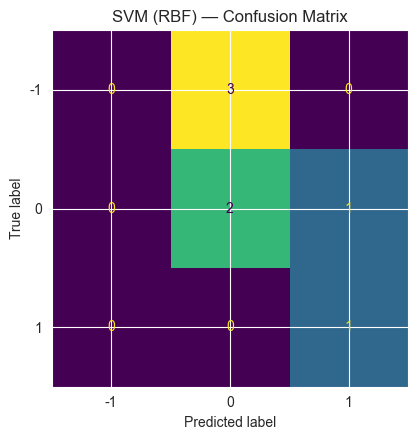


Logistic Regression (lbfgs) — best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}
Test Accuracy: 0.2857 | Macro-F1: 0.2619

Classification report:
              precision    recall  f1-score   support

          -1     1.0000    0.3333    0.5000         3
           0     0.2500    0.3333    0.2857         3
           1     0.0000    0.0000    0.0000         1

    accuracy                         0.2857         7
   macro avg     0.4167    0.2222    0.2619         7
weighted avg     0.5357    0.2857    0.3367         7



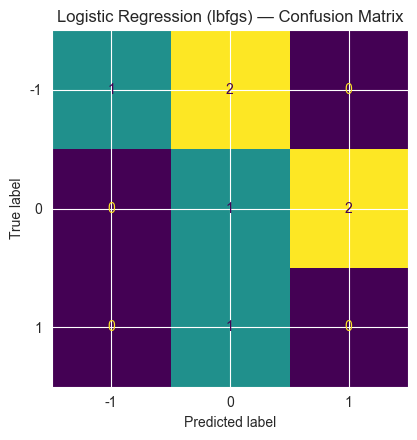


Random Forest — best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Test Accuracy: 0.5714 | Macro-F1: 0.4571

Classification report:
              precision    recall  f1-score   support

          -1     1.0000    0.6667    0.8000         3
           0     0.5000    0.6667    0.5714         3
           1     0.0000    0.0000    0.0000         1

    accuracy                         0.5714         7
   macro avg     0.5000    0.4444    0.4571         7
weighted avg     0.6429    0.5714    0.5878         7



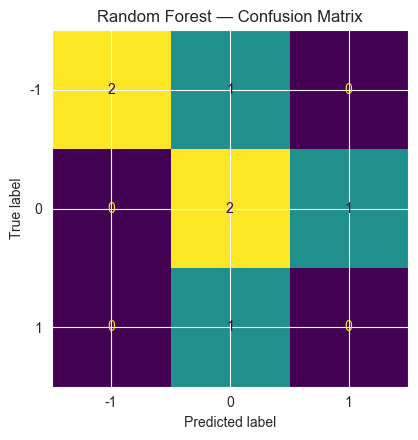

,Model,Test Accuracy,Macro F1,Best Params
2,Random Forest,0.5714,0.4571,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
0,SVM (RBF),0.4286,0.3889,"{'clf__C': 1, 'clf__gamma': 'scale'}"
1,Logistic Regression (lbfgs),0.2857,0.2619,"{'clf__C': 0.1, 'clf__penalty': 'l2'}"


In [6]:
# ===== Step 6: Execute once and compare models side-by-side =====
import pandas as pd

# reset results each time this cell runs
results = []

for name, est, grid in [
    ("SVM (RBF)", svm_pipe, svm_grid),
    ("Logistic Regression (lbfgs)", logreg_pipe, logreg_grid),
    ("Random Forest", rf_model, rf_grid),
]:
    results.append(fit_and_report(name, est, grid))

# Comparison table
cmp = pd.DataFrame([{
    "Model": r["Model"],
    "Test Accuracy": round(r["TestAccuracy"], 4),
    "Macro F1": round(r["MacroF1"], 4),
    "Best Params": r["BestParams"],
} for r in results]).sort_values(by="Macro F1", ascending=False)

display(cmp)


Random Forest — feature importances:


,importance
Ratio,0.332869
Portuguese_ships,0.196969
British_Dutch_total,0.187478
Dutch_ships,0.183217
Spanish_Involvement,0.062018
English_ships,0.037448


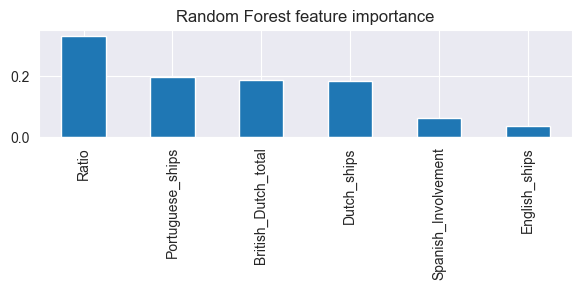

Logistic Regression — coefficients (per class vs rest):


,Portuguese_ships,Dutch_ships,English_ships,British_Dutch_total,Ratio,Spanish_Involvement
class_-1,-0.112284,0.143608,0.077019,0.150448,-0.228448,0.035528
class_0,0.044079,-0.068305,0.082289,-0.064077,0.044916,-0.016362
class_1,0.068205,-0.075303,-0.159308,-0.086371,0.183532,-0.019166


In [7]:
# ==== Step 6: Interpretability, feature importance / coefficients
# Random Forest importances
rf = next((r["Estimator"] for r in results if r["Model"] == "Random Forest"), None)
if rf is not None and hasattr(rf, "feature_importances_"):
    imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("Random Forest — feature importances:")
    display(imp.to_frame("importance"))

    plt.figure(figsize=(6,3))
    imp.plot(kind="bar")
    plt.title("Random Forest feature importance")
    plt.tight_layout()
    plt.show()

# Logistic Regression coefficients (multinomial: one row per class)
lr = next((r["Estimator"] for r in results if r["Model"].startswith("Logistic Regression")), None)
if lr is not None and hasattr(lr, "named_steps"):
    clf = lr.named_steps["clf"]
    scaler = lr.named_steps["scale"]
    # Coefs are in scaled space; still usable for directionality
    coef_df = pd.DataFrame(clf.coef_, columns=feature_cols, index=[f"class_{c}" for c in clf.classes_])
    print("Logistic Regression — coefficients (per class vs rest):")
    display(coef_df)


## Models Evaluated
Three classifiers were trained using the same preprocessing and stratified 3-fold CV with macro-F1 as the scoring metric.

| Model | Test Accuracy | Macro F1 | Best Parameters |
|-------|----------------|-----------|----------------|
| **Random Forest** | **0.5714** | **0.4571** | max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=400 |
| **SVM (RBF)** | 0.4286 | 0.3889 | C=1, gamma=‘scale’ |
| **Logistic Regression (lbfgs)** | 0.2857 | 0.2619 | C=0.1, penalty=‘l2’ |



## Result Interpretation

### 1. Random Forest
- **Performance:** Highest overall accuracy (57%) and macro-F1 (0.46).  
- **Confusion matrix:** Correctly classified most draws and some defeats, showing better generalization than the other models.  
- **Feature importance:**

| Feature | Importance |
|----------|-------------|
| **Ratio** | **0.332** |
| Portuguese_ships | 0.198 |
| British_Dutch_total | 0.188 |
| Dutch_ships | 0.182 |
| Spanish_Involvement | 0.062 |
| English_ships | 0.038 |

**Interpretation:**  
- The ratio of Portuguese to opposing ships was the single most influential variable, higher ratios typically led to victories.  
- Number of Portuguese ships and the size of the enemy fleet also mattered significantly.  
- Spanish involvement had a smaller but positive contribution, suggesting allied support may have influenced a few outcomes.

**Takeaway:**  
Random Forest captured non-linear and interaction effects effectively, making it the most suitable model for this small, mixed dataset.



### 2. SVM (RBF)
- **Performance:** Moderate accuracy (43%) and macro-F1 (0.39).  
- **Confusion matrix:** Correctly classified most draws but misidentified several defeats.  

**Interpretation:**  
The RBF kernel captured some nonlinear boundaries, but the limited data size restricted the model’s ability to find stable margins.
SVMs typically excel with larger, more balanced datasets and hence not ideal in this case.



### 3. Logistic Regression
- **Performance:** Lowest accuracy (28%) and macro-F1 (0.26).  
- **Coefficient interpretation (direction of effect):**

| Feature | Effect on Victory (class 1) | Effect on Defeat (class -1) |
|----------|------------------------------|------------------------------|
| Ratio | **+0.18** (more ships → victory) | **−0.23** (fewer ships → defeat) |
| Portuguese_ships | +0.07 | −0.11 |
| British_Dutch_total | −0.09 | +0.15 |
| Dutch_ships | −0.08 | +0.14 |
| Spanish_Involvement | −0.02 | +0.04 |

**Interpretation:**  
Logistic Regression confirms the same intuition — **the ship ratio strongly influences battle outcomes**.  
Positive coefficients for Portuguese ships and ratio indicate higher odds of victory, while larger Dutch fleets increase defeat likelihood.  
However, being linear, it failed to model the complexity captured by Random Forest or SVM.



## Confusion Matrix Insights
Across all models:
- **Victories were hardest to predict**, due to very few examples.  
- **Draws were most consistently identified.**  
- **Defeats were often confused with draws**, showing overlapping conditions and ship ratios.


## Model Comparison

| Model | Strengths | Weaknesses |
|--------|------------|------------|
| **Random Forest** | Best accuracy and interpretability; handles non-linearity and imbalance well | Can overfit on very small datasets |
| **SVM (RBF)** | Finds complex boundaries; robust to outliers | Needs more samples and balanced classes |
| **Logistic Regression** | Highly interpretable; shows direction of effects | Too linear; underfits complex data |



## Conclusion
- **Random Forest** delivered the best performance, confirming that it is the strongest determinant of victory.
- **SVM** performed reasonably but suffered from limited data.  
- **Logistic Regression** provided clarity on feature effects but lagged in accuracy.

**Overall insight:**  
For small, imbalanced historical datasets, tree-based ensemble methods like Random Forest are most effective.
They reveal both predictive strength and interpretable feature influence, aligning with intuitive naval warfare logic — the larger and better-supported fleet usually wins.